# Logistic Growth ODE: Interactive Exploration

This notebook lets you edit the parameters of the logistic growth equation

$$\frac{dP}{dt} = rP\left(1-\frac{P}{K}\right)$$

and see how the exact solution, the numerical solution, and the phase line all change.

Edit the values in the **Parameters** cell below, then re-run all cells (Runtime → Run all in Colab).

In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


## Parameters (edit these)

In [3]:
K = 100_000.0   # carrying capacity
r = 0.5         # growth rate
P0 = 100.0      # initial population
t_span = (0, 24)
t_eval = np.linspace(*t_span, 400)

## Exact solution

Derived by separation of variables + partial fractions:

$$P(t) = \frac{K}{1+Ae^{-rt}}, \qquad A = \frac{K-P_0}{P_0}$$

In [4]:
def logistic_exact(t, K=K, r=r, P0=P0):
    A = (K - P0) / P0
    return K / (1 + A * np.exp(-r * t))

P_exact = logistic_exact(t_eval)

## Numerical solution (cross-check)

In [5]:
def logistic_rhs(t, P, r=r, K=K):
    return r * P * (1 - P / K)

sol = solve_ivp(logistic_rhs, t_span, [P0], t_eval=t_eval,
                 method="RK45", rtol=1e-9, atol=1e-9)
P_numeric = sol.y[0]

max_abs_error = np.max(np.abs(P_numeric - P_exact))
print(f"Max |numeric - exact| over t in {t_span}: {max_abs_error:.6e}")

Max |numeric - exact| over t in (0, 24): 3.900020e-04


## Plot: P(t) time series

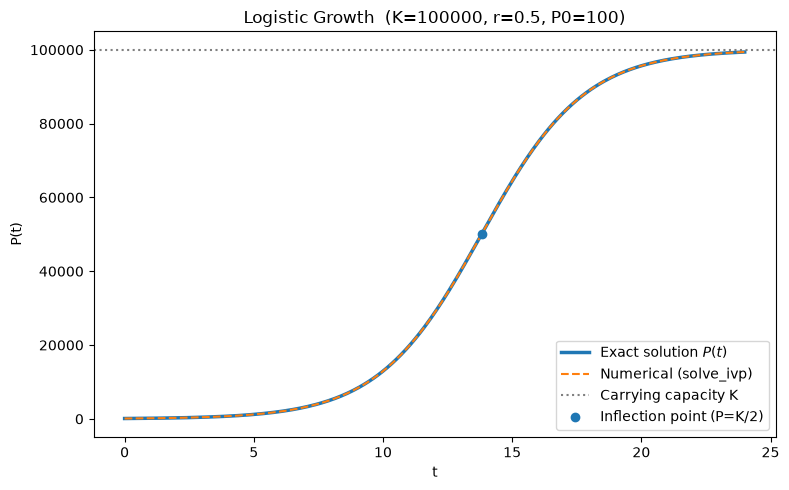

Inflection point: t = 13.814, P = 50000.0


In [6]:
t_inflection = np.log((K - P0) / P0) / r

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t_eval, P_exact, label="Exact solution $P(t)$", linewidth=2.5)
ax.plot(t_eval, P_numeric, "--", label="Numerical (solve_ivp)", linewidth=1.5)
ax.axhline(K, linestyle=":", color="gray", label="Carrying capacity K")
ax.scatter([t_inflection], [K / 2], zorder=5, label="Inflection point (P=K/2)")
ax.set_xlabel("t")
ax.set_ylabel("P(t)")
ax.set_title(f"Logistic Growth  (K={K:.0f}, r={r}, P0={P0:.0f})")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Inflection point: t = {t_inflection:.3f}, P = {K/2:.1f}")

## Plot: phase line dP/dt vs. P (equilibria and stability)

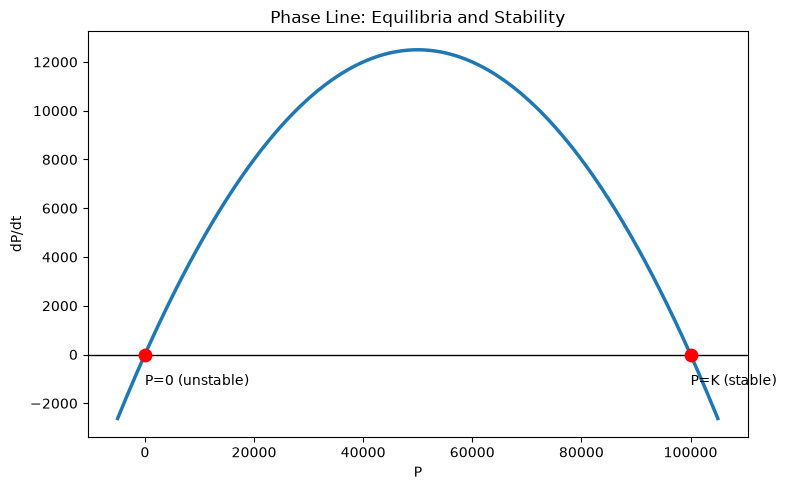

In [7]:
P_range = np.linspace(-0.05 * K, 1.05 * K, 400)
dPdt = r * P_range * (1 - P_range / K)

fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.plot(P_range, dPdt, linewidth=2.5)
ax2.axhline(0, color="black", linewidth=1)
ax2.scatter([0, K], [0, 0], s=80, zorder=5, color="red")
ax2.annotate("P=0 (unstable)", xy=(0, 0), xytext=(0, -0.1 * K * r / 4))
ax2.annotate("P=K (stable)", xy=(K, 0), xytext=(K, -0.1 * K * r / 4))
ax2.set_xlabel("P")
ax2.set_ylabel("dP/dt")
ax2.set_title("Phase Line: Equilibria and Stability")
plt.tight_layout()
plt.show()

## Try it yourself

Go back to the **Parameters** cell and try:
- Increasing `r` — does the curve reach K faster or slower?
- Setting `P0` close to `K` — what happens to the shape of the curve?
- Setting `P0` greater than `K` — the model still solves, but what does that mean physically?

Then re-run all cells to see the updated plots.